# Χρηματοοικονομικά Μαθηματικά με Python

## Δύο συμπληρωματικά case studies

Η εργασία χωρίζεται σε δύο ανεξάρτητα και καθαρά ερωτήματα:

1. **Προσωπικό ελληνικό χαρτοφυλάκιο:** ποια απλή στρατηγική κατανομής είχε καλύτερη ιστορική συμπεριφορά;
2. **Machine Learning στον ευρωπαϊκό πετρελαϊκό κλάδο:** μπορούν MLP και LSTM να προβλέψουν αν η Repsol θα έχει θετική απόδοση στις επόμενες 20 συνεδριάσεις και να υποστηρίξουν αποφάσεις BUY/HOLD/SELL;

Τα δεδομένα ανανεώνονται μέχρι την ημέρα εκτέλεσης. Όλα τα αποτελέσματα είναι εκπαιδευτικά και δεν αποτελούν επενδυτική συμβουλή.

## Παράμετροι

Αυτό είναι το βασικό κελί που μπορεί να τροποποιηθεί. Οι υπόλοιποι υπολογισμοί προσαρμόζονται αυτόματα.

In [1]:
# =========================
# ΚΟΙΝΕΣ ΡΥΘΜΙΣΕΙΣ
# =========================
START_DATE = "2018-01-01"
TRANSACTION_COST_BPS = 25
INITIAL_CAPITAL = 100_000
RANDOM_SEED = 42

# CASE STUDY 1: προσωπικό ελληνικό χαρτοφυλάκιο
GREEK_TICKERS = {
    "CENER.AT": "CENERGY",
    "ALWN.AT": "ALLWYN",
    "GEKTERNA.AT": "GEK_TERNA",
    "HTO.AT": "OTE",
    "PPC.AT": "PPC",
    "EYDAP.AT": "EYDAP",
    "AEGN.AT": "AEGEAN",
    "MOH.AT": "MOTOR_OIL",
    "FOYRK.AT": "FOYRK",
    "VIO.AT": "VIOHALCO",
}
MOMENTUM_DAYS = 60
VOLATILITY_DAYS = 20
TOP_STOCKS = 2

# CASE STUDY 2: ευρωπαϊκός πετρελαϊκός κλάδος
OIL_TICKERS = {
    "REP.DE": "REPSOL",
    "TTE.PA": "TOTALENERGIES",
    "SHELL.AS": "SHELL",
    "ENI.MI": "ENI",
    "EXH1.DE": "EUROPE_OIL_GAS_ETF",
}
TARGET = "REPSOL"
ML_LOOKBACK = 20
FORECAST_HORIZON = 20
POSITIVE_RETURN_THRESHOLD = 0.01
BUY_PROBABILITY = 0.55
TRAIN_PERCENTAGE = 0.80
EPOCHS = 30

# Case Study 1 — Προσωπικό ελληνικό χαρτοφυλάκιο

Εξετάζονται οι μετοχές που επιλέχθηκαν ως πιθανό προσωπικό επενδυτικό σύμπαν. Δεν χρησιμοποιείται Markowitz/Minimum Variance.

Οι στρατηγικές είναι:

- **Buy & Hold:** ίση αρχική επένδυση και καμία ανακατανομή.
- **Equal Weight:** επαναφορά σε ίσα βάρη κάθε μήνα.
- **Inverse Volatility:** μεγαλύτερα βάρη στις λιγότερο ευμετάβλητες μετοχές.
- **Momentum Top-2:** επιλογή των δύο μετοχών με την υψηλότερη θετική απόδοση 60 ημερών και inverse-volatility στάθμιση.

Τα σήματα του τέλους της ημέρας εφαρμόζονται την επόμενη συνεδρίαση και αφαιρούνται κόστη συναλλαγών.

In [2]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TODAY_EXCLUSIVE = (
    pd.Timestamp.today().normalize() + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")


def download_adjusted_prices(ticker_map, cache_file):
    """Λήψη adjusted close μέχρι σήμερα, με τοπικό cache ως fallback."""
    cache_file = Path(cache_file)
    try:
        raw = yf.download(
            list(ticker_map), start=START_DATE, end=TODAY_EXCLUSIVE,
            auto_adjust=True, group_by="ticker", progress=False, threads=False
        )
        prices = pd.DataFrame({
            name: raw[(ticker, "Close")] for ticker, name in ticker_map.items()
        }).dropna()
        if prices.empty or any(prices[column].notna().sum() < 500 for column in prices):
            raise ValueError("Η λήψη δεν επέστρεψε επαρκές ιστορικό.")
        prices.index = pd.to_datetime(prices.index).tz_localize(None)
        prices.index.name = "Date"
        prices.to_csv(cache_file)
        source = "Yahoo Finance — νέα λήψη"
    except Exception as error:
        if not cache_file.exists():
            raise RuntimeError("Απέτυχε η λήψη και δεν υπάρχει cache.") from error
        prices = pd.read_csv(cache_file, index_col="Date", parse_dates=True)
        source = f"Τοπικό cache — {error}"
    return prices, source


greek_prices, greek_source = download_adjusted_prices(
    GREEK_TICKERS, "case1_greek_prices_latest.csv"
)

display(Markdown(
    f"**Πηγή:** {greek_source}  \n"
    f"**Περίοδος:** {greek_prices.index.min().date()} έως "
    f"{greek_prices.index.max().date()}  \n"
    f"**Μετοχές:** {len(greek_prices.columns)} | "
    f"**Παρατηρήσεις:** {len(greek_prices):,}"
))
display(greek_prices.tail())

**Πηγή:** Yahoo Finance — νέα λήψη  
**Περίοδος:** 2018-01-02 έως 2026-08-13  
**Μετοχές:** 10 | **Παρατηρήσεις:** 2,135

,CENERGY,ALLWYN,GEK_TERNA,OTE,PPC,EYDAP,AEGEAN,MOTOR_OIL,FOYRK,VIOHALCO
Date,,,,,,,,,,
2026-08-07,23.000000,13.490,44.540001,19.780001,21.940001,10.98,12.37,53.000000,4.110,18.059999
2026-08-10,22.240000,13.535,44.860001,19.660000,21.760000,10.86,12.17,53.000000,4.065,18.000000
2026-08-11,22.200001,13.520,44.980000,19.549999,22.100000,11.50,12.27,53.150002,4.070,17.980000
2026-08-12,23.400000,13.500,44.279999,19.660000,22.080000,11.80,12.13,53.150002,4.055,17.900000
2026-08-13,23.299999,13.435,44.299999,19.660000,22.080000,11.82,12.11,53.200001,4.060,17.980000


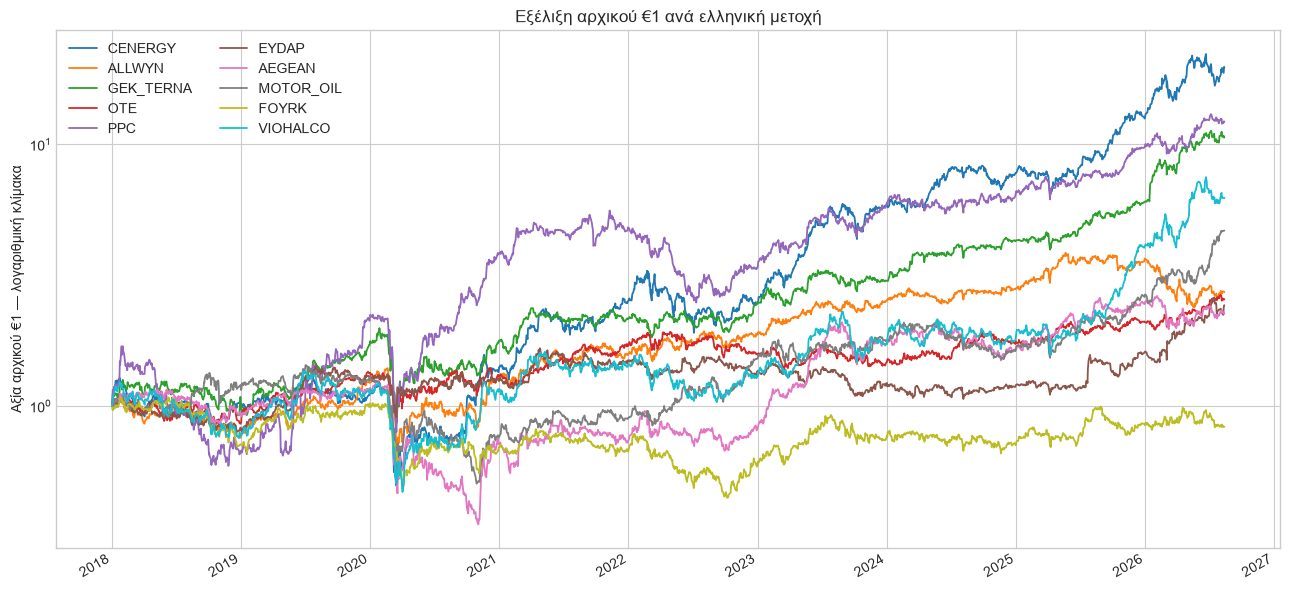

In [3]:
normalized = greek_prices / greek_prices.iloc[0]
ax = normalized.plot(figsize=(13, 6), logy=True, linewidth=1.3)
ax.set_title("Εξέλιξη αρχικού €1 ανά ελληνική μετοχή")
ax.set_ylabel("Αξία αρχικού €1 — λογαριθμική κλίμακα")
ax.set_xlabel("")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

### Βοηθητικές συναρτήσεις backtest

Το επόμενο κελί περιέχει τους τεχνικούς υπολογισμούς και ανοίγει κρυμμένο. Δεν χρειάζεται αλλαγή για την κανονική εκτέλεση.

In [4]:
GREEK_ASSETS = list(GREEK_TICKERS.values())
greek_returns = greek_prices.pct_change(fill_method=None)


def month_end_dates(index, start):
    eligible = pd.DatetimeIndex(index[index >= start])
    dates = pd.Series(eligible, index=eligible).groupby(
        eligible.to_period("M")
    ).max().tolist()
    # Do not treat the still-open current month as a completed rebalance date.
    if dates and pd.Timestamp(dates[-1]).to_period("M") == eligible[-1].to_period("M"):
        dates = dates[:-1]
    return pd.DatetimeIndex(sorted(set([eligible[0], *dates])))


def inverse_vol_weights(returns_window, columns):
    volatility = returns_window[columns].std(ddof=1).replace(0, np.nan)
    inverse = 1 / volatility
    weights = inverse / inverse.sum()
    return weights.fillna(0)


def build_case1_targets(signal_dates):
    equal_rows, inverse_rows, momentum_rows = [], [], []
    momentum_scores = greek_prices.pct_change(MOMENTUM_DAYS, fill_method=None)

    for date in signal_dates:
        equal_rows.append(pd.Series(1 / len(GREEK_ASSETS), index=GREEK_ASSETS))

        recent_returns = greek_returns.loc[:date].tail(VOLATILITY_DAYS)
        inverse_rows.append(inverse_vol_weights(recent_returns, GREEK_ASSETS))

        selected = momentum_scores.loc[date]
        selected = selected[selected > 0].nlargest(TOP_STOCKS).index
        weights = pd.Series(0.0, index=GREEK_ASSETS)
        if len(selected):
            weights.loc[selected] = inverse_vol_weights(recent_returns, selected)
        momentum_rows.append(weights)

    buy_hold = pd.DataFrame(
        [pd.Series(1 / len(GREEK_ASSETS), index=GREEK_ASSETS)],
        index=[signal_dates[0]],
    )
    return {
        "Buy & Hold Equal": buy_hold,
        "Equal Weight Monthly": pd.DataFrame(equal_rows, index=signal_dates),
        "Inverse Volatility": pd.DataFrame(inverse_rows, index=signal_dates),
        "Momentum Top-2": pd.DataFrame(momentum_rows, index=signal_dates),
    }, momentum_scores


def event_backtest(asset_returns, target_weights):
    """Signal today, execution next day, actual drift and transaction costs."""
    target_weights = target_weights.reindex(columns=GREEK_ASSETS).fillna(0)
    asset_values = pd.Series(0.0, index=GREEK_ASSETS)
    cash = float(INITIAL_CAPITAL)
    previous_nav = float(INITIAL_CAPITAL)
    pending_target = None
    cost_rate = TRANSACTION_COST_BPS / 10_000

    net_returns, equity, turnover, costs = [], [], [], []

    for date in asset_returns.index:
        daily_turnover = 0.0
        daily_cost = 0.0

        if pending_target is not None:
            pre_trade_nav = float(asset_values.sum() + cash)
            desired_values = pre_trade_nav * pending_target
            estimated_trade = float((desired_values - asset_values).abs().sum())
            daily_cost = estimated_trade * cost_rate
            investable_nav = max(pre_trade_nav - daily_cost, 0)
            new_values = investable_nav * pending_target
            traded = float((new_values - asset_values).abs().sum())
            daily_turnover = traded / pre_trade_nav if pre_trade_nav else 0
            asset_values = new_values
            cash = investable_nav * max(1 - float(pending_target.sum()), 0)

        asset_values = asset_values * (1 + asset_returns.loc[date].fillna(0))
        nav = float(asset_values.sum() + cash)
        net_returns.append(nav / previous_nav - 1)
        equity.append(nav / INITIAL_CAPITAL)
        turnover.append(daily_turnover)
        costs.append(daily_cost)
        previous_nav = nav

        pending_target = (
            target_weights.loc[date].copy()
            if date in target_weights.index else None
        )

    equity = pd.Series(equity, index=asset_returns.index)
    return {
        "returns": pd.Series(net_returns, index=asset_returns.index),
        "equity": equity,
        "drawdown": equity / equity.cummax() - 1,
        "turnover": pd.Series(turnover, index=asset_returns.index),
        "costs": pd.Series(costs, index=asset_returns.index),
    }


def performance_statistics(result):
    returns = result["returns"]
    equity = result["equity"]
    years = max((returns.index[-1] - returns.index[0]).days / 365.25, 1 / 365.25)
    annual_return = equity.iloc[-1] ** (1 / years) - 1
    annual_volatility = returns.std(ddof=1) * np.sqrt(252)
    sharpe = returns.mean() / returns.std(ddof=1) * np.sqrt(252)
    downside = np.sqrt(np.mean(np.minimum(returns, 0) ** 2)) * np.sqrt(252)
    return pd.Series({
        "Συνολική απόδοση": equity.iloc[-1] - 1,
        "Ετησιοποιημένη απόδοση": annual_return,
        "Μεταβλητότητα": annual_volatility,
        "Sharpe": sharpe,
        "Sortino": returns.mean() * 252 / downside if downside else np.nan,
        "Maximum drawdown": result["drawdown"].min(),
        "Turnover": result["turnover"].sum(),
        "Κόστη / αρχικό κεφάλαιο": result["costs"].sum() / INITIAL_CAPITAL,
    })

In [5]:
evaluation_start = greek_prices.index[252]
case1_returns = greek_returns.loc[evaluation_start:].dropna(how="all")
signal_dates = month_end_dates(case1_returns.index, evaluation_start)
case1_targets, momentum_scores = build_case1_targets(signal_dates)

case1_results = {
    name: event_backtest(case1_returns, target)
    for name, target in case1_targets.items()
}
case1_statistics = pd.DataFrame({
    name: performance_statistics(result)
    for name, result in case1_results.items()
}).T.sort_values("Sharpe", ascending=False)

percentage_columns = [
    "Συνολική απόδοση", "Ετησιοποιημένη απόδοση", "Μεταβλητότητα",
    "Maximum drawdown", "Κόστη / αρχικό κεφάλαιο"
]
formats = {column: "{:.2%}" for column in percentage_columns}
formats.update({"Sharpe": "{:.3f}", "Sortino": "{:.3f}", "Turnover": "{:.2f}"})

display(Markdown(
    f"**Κοινή περίοδος αξιολόγησης:** {case1_returns.index.min().date()} έως "
    f"{case1_returns.index.max().date()}  \n"
    f"**Κόστος συναλλαγής:** {TRANSACTION_COST_BPS} bps"
))
display(case1_statistics.style.format(formats))

**Κοινή περίοδος αξιολόγησης:** 2019-01-07 έως 2026-08-13  
**Κόστος συναλλαγής:** 25 bps

,Συνολική απόδοση,Ετησιοποιημένη απόδοση,Μεταβλητότητα,Sharpe,Sortino,Maximum drawdown,Turnover,Κόστη / αρχικό κεφάλαιο
Buy & Hold Equal,627.14%,29.84%,25.06%,1.187,1.655,-50.63%,1.00,0.25%
Equal Weight Monthly,519.63%,27.13%,23.78%,1.147,1.596,-49.47%,5.80,3.25%
Inverse Volatility,431.36%,24.59%,22.34%,1.114,1.544,-47.27%,23.21,12.88%
Momentum Top-2,290.99%,19.66%,26.59%,0.820,1.205,-37.27%,105.75,52.33%


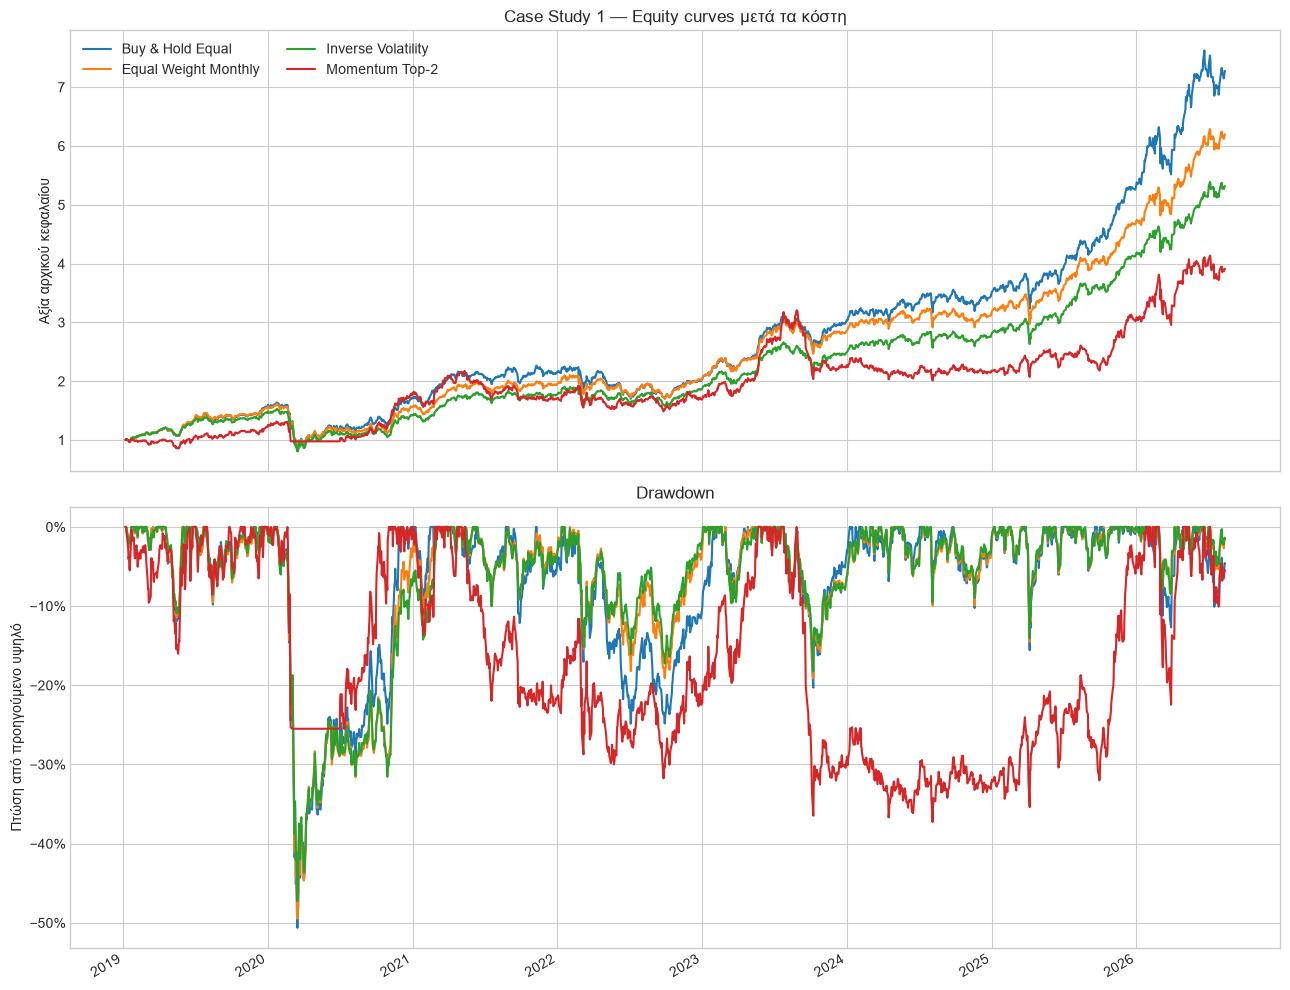

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
for name, result in case1_results.items():
    result["equity"].plot(ax=axes[0], label=name)
    result["drawdown"].plot(ax=axes[1], label=name)

axes[0].set_title("Case Study 1 — Equity curves μετά τα κόστη")
axes[0].set_ylabel("Αξία αρχικού κεφαλαίου")
axes[0].legend(ncol=2)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Πτώση από προηγούμενο υψηλό")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

In [7]:
best_return = case1_statistics["Ετησιοποιημένη απόδοση"].idxmax()
best_sharpe = case1_statistics["Sharpe"].idxmax()
smallest_drawdown = case1_statistics["Maximum drawdown"].idxmax()
latest_date = greek_prices.index[-1]
latest_scores = momentum_scores.loc[latest_date]
latest_selected = latest_scores[latest_scores > 0].nlargest(TOP_STOCKS).index
latest_momentum = pd.Series(0.0, index=GREEK_ASSETS)
if len(latest_selected):
    latest_window = greek_returns.loc[:latest_date].tail(VOLATILITY_DAYS)
    latest_momentum.loc[latest_selected] = inverse_vol_weights(
        latest_window, latest_selected
    )
selected = latest_momentum[latest_momentum > 0].sort_values(ascending=False)

case1_conclusion = [
    "### Ερμηνεία Case Study 1",
    f"- Μεγαλύτερη ετησιοποιημένη απόδοση: **{best_return}**.",
    f"- Καλύτερη σχέση απόδοσης/κινδύνου: **{best_sharpe}**.",
    f"- Μικρότερο maximum drawdown: **{smallest_drawdown}**.",
]
if case1_statistics.loc["Momentum Top-2", "Sharpe"] > case1_statistics.loc["Buy & Hold Equal", "Sharpe"]:
    case1_conclusion.append("- Το Momentum βελτίωσε ιστορικά το Sharpe έναντι του Buy & Hold.")
else:
    case1_conclusion.append("- Το Momentum **δεν** ξεπέρασε το Buy & Hold ως προς το Sharpe.")

case1_conclusion.append(
    f"- Προσωρινό τρέχον Momentum target στις **{latest_date.date()}**:"
)
if selected.empty:
    case1_conclusion.append("  - 100% μετρητά")
else:
    for stock, weight in selected.items():
        case1_conclusion.append(f"  - {stock}: **{weight:.1%}**")

display(Markdown("\n".join(case1_conclusion)))

### Ερμηνεία Case Study 1
- Μεγαλύτερη ετησιοποιημένη απόδοση: **Buy & Hold Equal**.
- Καλύτερη σχέση απόδοσης/κινδύνου: **Buy & Hold Equal**.
- Μικρότερο maximum drawdown: **Momentum Top-2**.
- Το Momentum **δεν** ξεπέρασε το Buy & Hold ως προς το Sharpe.
- Προσωρινό τρέχον Momentum target στις **2026-08-13**:
  - MOTOR_OIL: **57.9%**
  - EYDAP: **42.1%**

# Case Study 2 — ML/DL classification στον ευρωπαϊκό πετρελαϊκό κλάδο

## Ερευνητικό ερώτημα

Μπορούν οι πρόσφατες αποδόσεις της **Repsol, TotalEnergies, Shell, Eni και του EXH1 Oil & Gas ETF** να βοηθήσουν στην πρόβλεψη της κατεύθυνσης της Repsol για τις επόμενες 20 συνεδριάσεις;

Το μοντέλο έχει **πέντε σειρές εισόδου και μία έξοδο**:

- `1`: η μελλοντική απόδοση της Repsol αναμένεται να ξεπεράσει το +1%.
- `0`: η απόδοση δεν αναμένεται να ξεπεράσει το +1%.

Τα MLP και LSTM είναι classifiers. Δεν παράγουν απευθείας χαρτοφυλάκιο. Η πιθανότητα της θετικής κλάσης μετατρέπεται σε θέση Repsol ή μετρητά και στη συνέχεια σε BUY/HOLD/SELL.

**Πηγή:** Yahoo Finance — νέα λήψη  
**Περίοδος:** 2018-01-02 έως 2026-08-13  
**Παρατηρήσεις:** 2,179

,REPSOL,TOTALENERGIES,SHELL,ENI,EUROPE_OIL_GAS_ETF
Date,,,,,
2026-08-06,25.469999,74.540001,38.004002,23.400000,52.970001
2026-08-07,25.230000,74.089996,37.621807,23.280001,52.740002
2026-08-10,25.600000,75.540001,38.013805,23.575001,53.419998
2026-08-11,26.260000,76.589996,38.572399,24.049999,54.290001
2026-08-13,25.950001,75.129997,38.555000,23.620001,54.290001


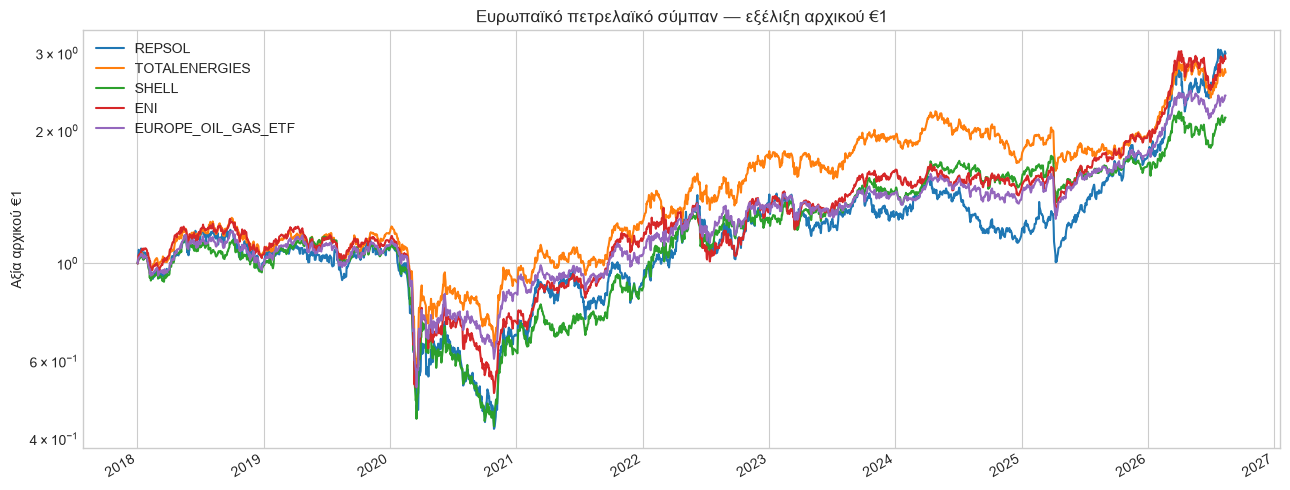

In [8]:
oil_prices, oil_source = download_adjusted_prices(
    OIL_TICKERS, "case2_oil_prices_latest.csv"
)

display(Markdown(
    f"**Πηγή:** {oil_source}  \n"
    f"**Περίοδος:** {oil_prices.index.min().date()} έως "
    f"{oil_prices.index.max().date()}  \n"
    f"**Παρατηρήσεις:** {len(oil_prices):,}"
))
display(oil_prices.tail())

oil_normalized = oil_prices / oil_prices.iloc[0]
ax = oil_normalized.plot(figsize=(13, 5), logy=True)
ax.set_title("Ευρωπαϊκό πετρελαϊκό σύμπαν — εξέλιξη αρχικού €1")
ax.set_ylabel("Αξία αρχικού €1")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Χρονικός διαχωρισμός και αποφυγή leakage

- Τα μοντέλα βλέπουν τις προηγούμενες 20 ημερήσιες αποδόσεις.
- Το τελευταίο 20% αποτελεί ανέγγιχτο test set.
- Μεταξύ training, validation και test αφήνεται κενό 20 ημερών, επειδή ο στόχος κοιτάζει 20 ημέρες μπροστά.
- Ο scaler εκπαιδεύεται μόνο στο training set.
- Τα δεδομένα δεν ανακατεύονται τυχαία.

In [9]:
from sklearn.preprocessing import StandardScaler

oil_returns = oil_prices.pct_change(fill_method=None).dropna()
forward_return = oil_prices[TARGET].shift(-FORECAST_HORIZON) / oil_prices[TARGET] - 1

X, y, sample_dates, future_returns = [], [], [], []
for i in range(ML_LOOKBACK - 1, len(oil_returns) - FORECAST_HORIZON):
    date = oil_returns.index[i]
    future = forward_return.loc[date]
    X.append(oil_returns.iloc[i - ML_LOOKBACK + 1:i + 1].values)
    y.append(int(future > POSITIVE_RETURN_THRESHOLD))
    sample_dates.append(date)
    future_returns.append(future)

X = np.asarray(X)
y = np.asarray(y)
sample_dates = pd.DatetimeIndex(sample_dates)
future_returns = np.asarray(future_returns)

test_start = int(len(X) * TRAIN_PERCENTAGE)
train_end = test_start - FORECAST_HORIZON
validation_size = int(train_end * 0.15)
validation_start = train_end - validation_size
fit_end = validation_start - FORECAST_HORIZON

X_fit_raw, y_fit = X[:fit_end], y[:fit_end]
X_validation_raw, y_validation = X[validation_start:train_end], y[validation_start:train_end]
X_test_raw, y_test = X[test_start:], y[test_start:]
test_dates = sample_dates[test_start:]

scaler = StandardScaler()
scaler.fit(X_fit_raw.reshape(-1, X.shape[2]))

def scale_sequences(values):
    return scaler.transform(values.reshape(-1, X.shape[2])).reshape(values.shape)

X_fit = scale_sequences(X_fit_raw)
X_validation = scale_sequences(X_validation_raw)
X_test = scale_sequences(X_test_raw)

display(Markdown(
    f"**Training:** {sample_dates[0].date()} έως {sample_dates[fit_end - 1].date()}  \n"
    f"**Validation:** {sample_dates[validation_start].date()} έως "
    f"{sample_dates[train_end - 1].date()}  \n"
    f"**Test:** {test_dates[0].date()} έως {test_dates[-1].date()}  \n"
    f"**Θετική κλάση:** {y_fit.mean():.1%} training | {y_test.mean():.1%} test"
))

**Training:** 2018-01-30 έως 2023-09-04  
**Validation:** 2023-10-03 έως 2024-09-30  
**Test:** 2024-10-29 έως 2026-07-14  
**Θετική κλάση:** 50.1% training | 67.1% test

In [10]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, LSTM
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_SEED)

mlp = Sequential([
    Input(shape=(ML_LOOKBACK, X.shape[2])),
    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid"),
])
mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

lstm = Sequential([
    Input(shape=(ML_LOOKBACK, X.shape[2])),
    LSTM(16),
    Dropout(0.20),
    Dense(1, activation="sigmoid"),
])
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

display(Markdown(
    f"**MLP παράμετροι:** {mlp.count_params():,}  \n"
    f"**LSTM παράμετροι:** {lstm.count_params():,}"
))

**MLP παράμετροι:** 3,265  
**LSTM παράμετροι:** 1,425

In [11]:
history_mlp = mlp.fit(
    X_fit, y_fit,
    validation_data=(X_validation, y_validation),
    epochs=EPOCHS, batch_size=32, shuffle=False,
    callbacks=[early_stop], verbose=0,
)
history_lstm = lstm.fit(
    X_fit, y_fit,
    validation_data=(X_validation, y_validation),
    epochs=EPOCHS, batch_size=32, shuffle=False,
    callbacks=[early_stop], verbose=0,
)

mlp_probability = mlp.predict(X_test, verbose=0).ravel()
lstm_probability = lstm.predict(X_test, verbose=0).ravel()

display(Markdown(
    f"**MLP epochs:** {len(history_mlp.history['loss'])}  \n"
    f"**LSTM epochs:** {len(history_lstm.history['loss'])}"
))

**MLP epochs:** 25  
**LSTM epochs:** 20

## Αξιολόγηση classification

- **Accuracy:** συνολικό ποσοστό σωστών προβλέψεων.
- **Balanced accuracy:** δίνει ίση σημασία στις δύο κλάσεις.
- **Precision:** πόσα από τα θετικά σήματα ήταν πράγματι θετικά.
- **Recall:** πόσες από τις θετικές περιόδους εντόπισε το μοντέλο.
- **F1:** ισορροπία precision και recall.
- **ROC AUC:** ποιότητα κατάταξης ανεξάρτητα από ένα συγκεκριμένο probability threshold. Το 0,50 αντιστοιχεί περίπου σε τυχαία κατάταξη.

In [12]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

def classification_statistics(actual, probability):
    prediction = (probability >= 0.50).astype(int)
    return pd.Series({
        "Accuracy": accuracy_score(actual, prediction),
        "Balanced accuracy": balanced_accuracy_score(actual, prediction),
        "Precision": precision_score(actual, prediction, zero_division=0),
        "Recall": recall_score(actual, prediction, zero_division=0),
        "F1": f1_score(actual, prediction, zero_division=0),
        "ROC AUC": roc_auc_score(actual, probability),
    })

majority_class = int(y_fit.mean() >= 0.50)
majority_probability = np.repeat(float(majority_class), len(y_test))

classification_table = pd.DataFrame({
    "Majority baseline": classification_statistics(y_test, majority_probability),
    "MLP": classification_statistics(y_test, mlp_probability),
    "LSTM": classification_statistics(y_test, lstm_probability),
}).T

display(classification_table.style.format("{:.3f}"))

best_auc = classification_table["ROC AUC"].idxmax()
best_balanced = classification_table["Balanced accuracy"].idxmax()
classification_conclusion = [
    "### Ερμηνεία classification",
    f"- Καλύτερο ROC AUC: **{best_auc}**.",
    f"- Καλύτερο balanced accuracy: **{best_balanced}**.",
]
for model_name in ["MLP", "LSTM"]:
    auc = classification_table.loc[model_name, "ROC AUC"]
    if auc < 0.55:
        classification_conclusion.append(
            f"- Το {model_name} έχει ROC AUC {auc:.3f}, κοντά στην τυχαία κατάταξη."
        )
    else:
        classification_conclusion.append(
            f"- Το {model_name} έχει ROC AUC {auc:.3f}, άρα εμφανίζει κάποια προγνωστική ικανότητα στο test."
        )
display(Markdown("\n".join(classification_conclusion)))

,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC
Majority baseline,0.671,0.500,0.671,1.000,0.803,0.500
MLP,0.498,0.496,0.667,0.502,0.573,0.483
LSTM,0.428,0.427,0.603,0.429,0.501,0.378


### Ερμηνεία classification
- Καλύτερο ROC AUC: **Majority baseline**.
- Καλύτερο balanced accuracy: **Majority baseline**.
- Το MLP έχει ROC AUC 0.483, κοντά στην τυχαία κατάταξη.
- Το LSTM έχει ROC AUC 0.378, κοντά στην τυχαία κατάταξη.

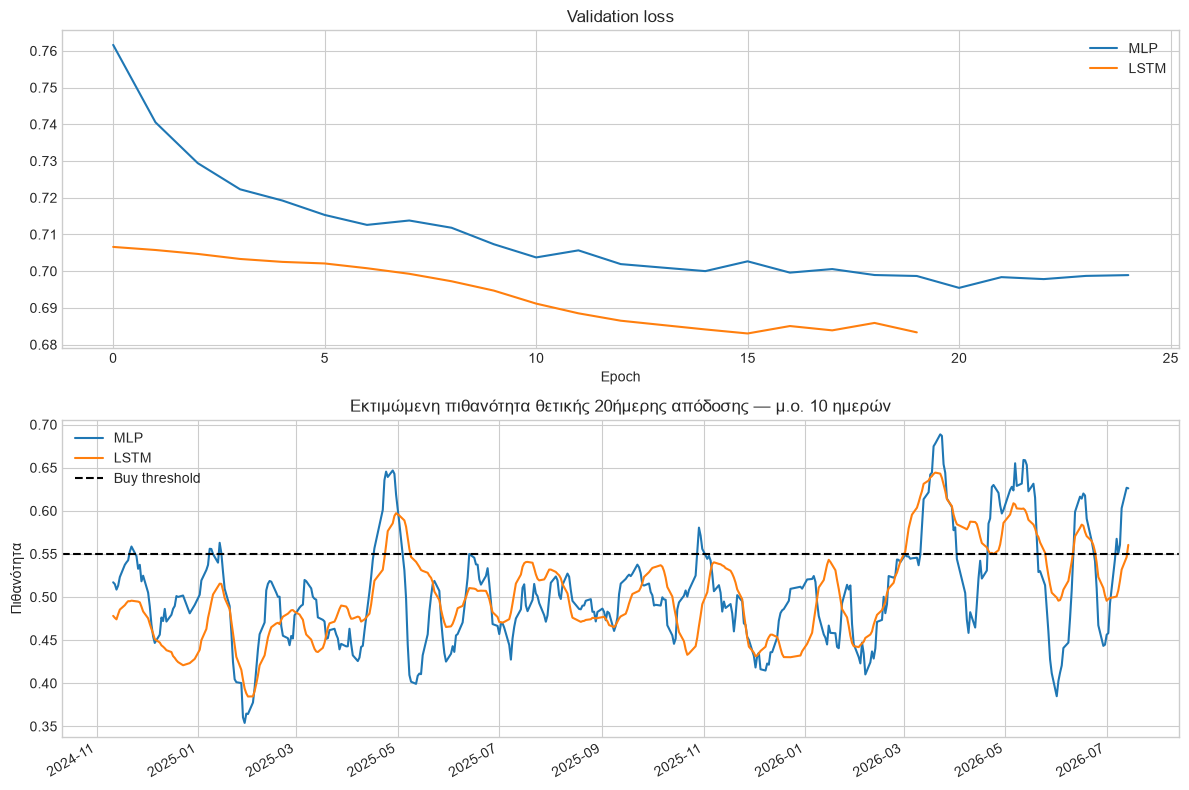

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(history_mlp.history["val_loss"], label="MLP")
axes[0].plot(history_lstm.history["val_loss"], label="LSTM")
axes[0].set_title("Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

probability_plot = pd.DataFrame({
    "MLP": mlp_probability,
    "LSTM": lstm_probability,
}, index=test_dates).rolling(10).mean()
probability_plot.plot(ax=axes[1])
axes[1].axhline(BUY_PROBABILITY, color="black", linestyle="--", label="Buy threshold")
axes[1].set_title("Εκτιμώμενη πιθανότητα θετικής 20ήμερης απόδοσης — μ.ο. 10 ημερών")
axes[1].set_ylabel("Πιθανότητα")
axes[1].set_xlabel("")
axes[1].legend()
plt.tight_layout()
plt.show()

## Από πιθανότητα σε BUY/HOLD/SELL

Η απόφαση λαμβάνεται στο τέλος κάθε μήνα:

- πιθανότητα τουλάχιστον 55% → θέση στη Repsol,
- μικρότερη πιθανότητα → μετρητά.

Η αλλαγή κατάστασης δίνει την ονομασία της ενέργειας:

- μετρητά → μετοχή: **BUY**,
- μετοχή → μετοχή: **HOLD**,
- μετοχή → μετρητά: **SELL**,
- μετρητά → μετρητά: **CASH**.

Το Buy & Hold της Repsol παραμένει το βασικό επενδυτικό benchmark.

In [14]:
def monthly_actions(probability, dates, current_data_date):
    probability = pd.Series(probability, index=dates)
    month_end_probability = probability.groupby(
        probability.index.to_period("M")
    ).tail(1)
    current_period = pd.Timestamp(current_data_date).to_period("M")
    month_end_probability = month_end_probability[
        month_end_probability.index.to_period("M") < current_period
    ]
    desired_position = (month_end_probability >= BUY_PROBABILITY).astype(float)

    actions = []
    previous = 0.0
    for current in desired_position:
        if previous == 0 and current == 1:
            actions.append("BUY")
        elif previous == 1 and current == 1:
            actions.append("HOLD")
        elif previous == 1 and current == 0:
            actions.append("SELL")
        else:
            actions.append("CASH")
        previous = current

    return pd.DataFrame({
        "Probability": month_end_probability,
        "Position": desired_position,
        "Action": actions,
    })


def timing_backtest(action_table, daily_target_returns):
    signal = action_table["Position"]
    position = signal.reindex(daily_target_returns.index).ffill().shift(1).fillna(0)
    turnover = position.diff().abs()
    turnover.iloc[0] = position.iloc[0]
    costs = turnover * TRANSACTION_COST_BPS / 10_000
    strategy_returns = position * daily_target_returns - costs
    equity = (1 + strategy_returns).cumprod()
    return {
        "returns": strategy_returns,
        "equity": equity,
        "drawdown": equity / equity.cummax() - 1,
        "turnover": turnover,
        "costs": costs * INITIAL_CAPITAL,
    }


def buy_hold_backtest(daily_target_returns):
    returns = daily_target_returns.copy()
    returns.iloc[0] -= TRANSACTION_COST_BPS / 10_000
    equity = (1 + returns).cumprod()
    return {
        "returns": returns,
        "equity": equity,
        "drawdown": equity / equity.cummax() - 1,
        "turnover": pd.Series([1.0], index=[returns.index[0]]),
        "costs": pd.Series([INITIAL_CAPITAL * TRANSACTION_COST_BPS / 10_000], index=[returns.index[0]]),
    }

In [15]:
# Out-of-sample probabilities through the latest available market date.
all_prediction_dates = oil_returns.index[oil_returns.index >= test_dates[0]]
all_prediction_raw = []
for date in all_prediction_dates:
    location = oil_returns.index.get_loc(date)
    all_prediction_raw.append(
        oil_returns.iloc[location - ML_LOOKBACK + 1:location + 1].values
    )
all_prediction_raw = np.asarray(all_prediction_raw)
all_prediction_scaled = scale_sequences(all_prediction_raw)
all_mlp_probability = mlp.predict(all_prediction_scaled, verbose=0).ravel()
all_lstm_probability = lstm.predict(all_prediction_scaled, verbose=0).ravel()

mlp_actions = monthly_actions(
    all_mlp_probability, all_prediction_dates, oil_returns.index[-1]
)
lstm_actions = monthly_actions(
    all_lstm_probability, all_prediction_dates, oil_returns.index[-1]
)

strategy_start = test_dates[0]
strategy_end = oil_returns.index[-1]
repsol_test_returns = oil_returns[TARGET].loc[strategy_start:strategy_end]

case2_results = {
    "Repsol Buy & Hold": buy_hold_backtest(repsol_test_returns),
    "MLP timing": timing_backtest(mlp_actions, repsol_test_returns),
    "LSTM timing": timing_backtest(lstm_actions, repsol_test_returns),
}
case2_statistics = pd.DataFrame({
    name: performance_statistics(result)
    for name, result in case2_results.items()
}).T.sort_values("Sharpe", ascending=False)

display(case2_statistics.style.format(formats))
display(Markdown("**Τελευταίες αποφάσεις MLP**"))
display(mlp_actions.tail(8).style.format({"Probability": "{:.1%}", "Position": "{:.0f}"}))
display(Markdown("**Τελευταίες αποφάσεις LSTM**"))
display(lstm_actions.tail(8).style.format({"Probability": "{:.1%}", "Position": "{:.0f}"}))

,Συνολική απόδοση,Ετησιοποιημένη απόδοση,Μεταβλητότητα,Sharpe,Sortino,Maximum drawdown,Turnover,Κόστη / αρχικό κεφάλαιο
Repsol Buy & Hold,151.02%,67.33%,30.43%,1.855,2.731,-27.04%,1.00,0.25%
LSTM timing,21.31%,11.41%,17.40%,0.712,0.970,-20.48%,7.00,1.75%
MLP timing,1.50%,0.84%,9.77%,0.134,0.194,-11.14%,7.00,1.75%


**Τελευταίες αποφάσεις MLP**

,Probability,Position,Action
Date,,,
2025-12-30 00:00:00,49.0%,0,CASH
2026-01-30 00:00:00,22.8%,0,CASH
2026-02-27 00:00:00,50.6%,0,CASH
2026-03-31 00:00:00,52.7%,0,CASH
2026-04-30 00:00:00,77.0%,1,BUY
2026-05-29 00:00:00,30.4%,0,SELL
2026-06-30 00:00:00,53.0%,0,CASH
2026-07-30 00:00:00,58.4%,1,BUY


**Τελευταίες αποφάσεις LSTM**

,Probability,Position,Action
Date,,,
2025-12-30 00:00:00,48.4%,0,CASH
2026-01-30 00:00:00,45.3%,0,CASH
2026-02-27 00:00:00,57.3%,1,BUY
2026-03-31 00:00:00,56.3%,1,HOLD
2026-04-30 00:00:00,61.8%,1,HOLD
2026-05-29 00:00:00,45.9%,0,SELL
2026-06-30 00:00:00,48.3%,0,CASH
2026-07-30 00:00:00,60.3%,1,BUY


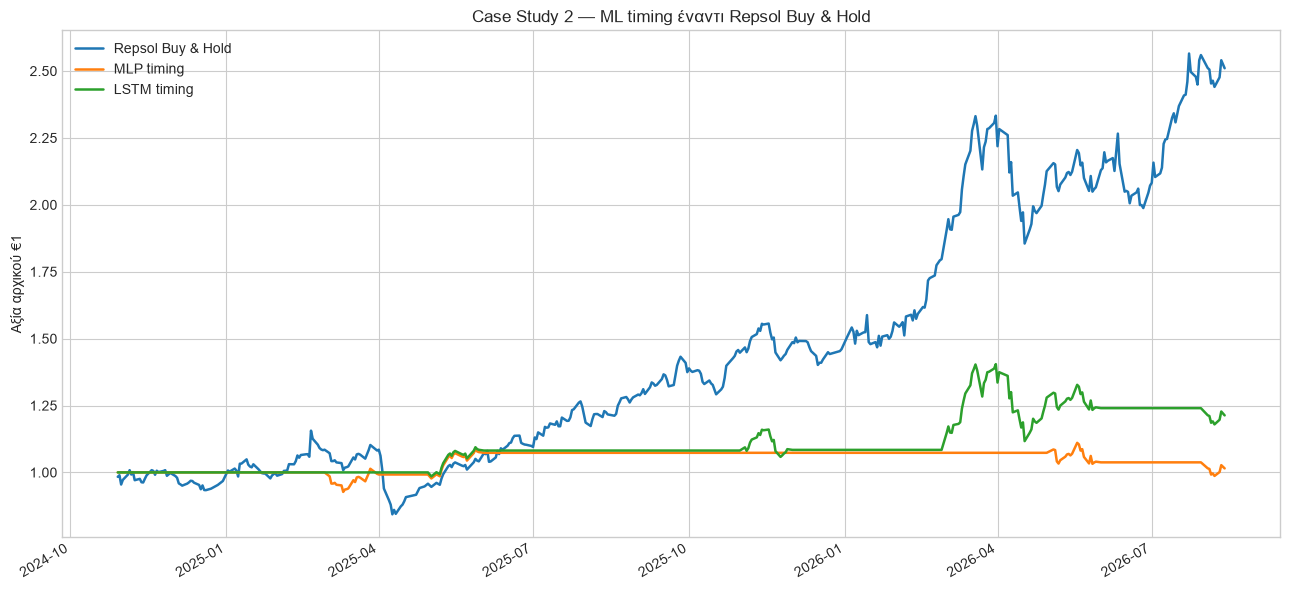

### Τελική ερμηνεία Case Study 2
- Καλύτερο Sharpe στην περίοδο test: **Repsol Buy & Hold**.
- Το MLP timing **δεν** ξεπέρασε το Buy & Hold ως προς το Sharpe.
- Το LSTM timing **δεν** ξεπέρασε το Buy & Hold ως προς το Sharpe.
- Η πρόβλεψη αξιολογείται μόνο out-of-sample και μετά από transaction costs.

In [16]:
ax = pd.DataFrame({
    name: result["equity"] for name, result in case2_results.items()
}).plot(figsize=(13, 6), linewidth=1.8)
ax.set_title("Case Study 2 — ML timing έναντι Repsol Buy & Hold")
ax.set_ylabel("Αξία αρχικού €1")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

best_case2 = case2_statistics["Sharpe"].idxmax()
case2_conclusion = [
    "### Τελική ερμηνεία Case Study 2",
    f"- Καλύτερο Sharpe στην περίοδο test: **{best_case2}**.",
]
for model_name in ["MLP timing", "LSTM timing"]:
    model_sharpe = case2_statistics.loc[model_name, "Sharpe"]
    benchmark_sharpe = case2_statistics.loc["Repsol Buy & Hold", "Sharpe"]
    if model_sharpe > benchmark_sharpe:
        case2_conclusion.append(
            f"- Το {model_name} βελτίωσε ιστορικά το Sharpe έναντι του Buy & Hold."
        )
    else:
        case2_conclusion.append(
            f"- Το {model_name} **δεν** ξεπέρασε το Buy & Hold ως προς το Sharpe."
        )

case2_conclusion.append(
    "- Η πρόβλεψη αξιολογείται μόνο out-of-sample και μετά από transaction costs."
)
display(Markdown("\n".join(case2_conclusion)))

In [17]:
# Πρόβλεψη με τα πιο πρόσφατα διαθέσιμα δεδομένα.
latest_raw_sequence = oil_returns.iloc[-ML_LOOKBACK:].values.reshape(
    1, ML_LOOKBACK, len(OIL_TICKERS)
)
latest_sequence = scale_sequences(latest_raw_sequence)
latest_mlp_probability = float(mlp.predict(latest_sequence, verbose=0).ravel()[0])
latest_lstm_probability = float(lstm.predict(latest_sequence, verbose=0).ravel()[0])

def probability_signal(probability):
    return "INVEST / BUY-HOLD" if probability >= BUY_PROBABILITY else "CASH / SELL"

display(Markdown(
    f"### Νεότερη ένδειξη — {oil_returns.index[-1].date()}  \n"
    f"- **MLP:** {latest_mlp_probability:.1%} → "
    f"**{probability_signal(latest_mlp_probability)}**  \n"
    f"- **LSTM:** {latest_lstm_probability:.1%} → "
    f"**{probability_signal(latest_lstm_probability)}**  \n\n"
    "Η ένδειξη αφορά το αν η Repsol θα ξεπεράσει απόδοση +1% στις επόμενες "
    "20 συνεδριάσεις. Η πραγματική έκβαση δεν είναι ακόμη γνωστή."
))

### Νεότερη ένδειξη — 2026-08-13  
- **MLP:** 54.0% → **CASH / SELL**  
- **LSTM:** 51.4% → **CASH / SELL**  

Η ένδειξη αφορά το αν η Repsol θα ξεπεράσει απόδοση +1% στις επόμενες 20 συνεδριάσεις. Η πραγματική έκβαση δεν είναι ακόμη γνωστή.

# Συνολικό συμπέρασμα

- Το **Case Study 1** συγκρίνει απλές, διαφανείς στρατηγικές πάνω στο ίδιο προσωπικό επενδυτικό σύμπαν.
- Το **Case Study 2** είναι διαφορετικό ερευνητικό πρόβλημα: supervised classification με 5 κλαδικά συνδεδεμένες εισόδους και 1 έξοδο.
- Το BUY/HOLD/SELL δεν είναι αυθαίρετη έξοδος του neural network. Προκύπτει από την πιθανότητα του classifier και την προηγούμενη επενδυτική θέση.
- Η υπεροχή ενός σύνθετου μοντέλου δεν θεωρείται δεδομένη. MLP και LSTM πρέπει να συγκρίνονται τόσο με απλό classification baseline όσο και με Repsol Buy & Hold μετά τα κόστη.
- Παραμένουν περιορισμοί: μικρό δείγμα, επιλογή σημερινών μετοχών, σταθερό transaction cost και απουσία φόρων/market impact.

## Ενδεικτική βιβλιογραφική βάση

- Stefan Jansen, *Machine Learning for Algorithmic Trading*: προβλέψεις → σήματα → στρατηγική → backtest.
- Marcos López de Prado, *Advances in Financial Machine Learning*: labeling, meta-labeling και αξιολόγηση στρατηγικών.
- Fischer & Krauss (2018), *Deep learning with long short-term memory networks for financial market predictions*.
- Gu, Kelly & Xiu (2020), *Empirical Asset Pricing via Machine Learning*.

Η σωστή διατύπωση είναι: **ελέγχουμε αν οι ML προβλέψεις έχουν πρόσθετη οικονομική αξία — δεν υποθέτουμε ότι την έχουν επειδή το μοντέλο είναι σύνθετο.**